# BCS overlap between distinct BCS phase states

This notebook demonstrates how to compute the overlap between two BCS ground states using `circuitfp` package.

The calculation reproduces Eq.(21) and Fig. 3(a) of [Y.-C. Lian, B. J. Powell and T. M. Stace, "Circuit quantization from first principles", *Phys. Rev. Research* **7**, 033144 (2025)](https://journals.aps.org/prresearch/abstract/10.1103/dfrq-44vk).

## Import packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from circuitfp.overlap import Overlap

For two BCS phase states of different phase parameters $| \Psi (\phi_1) \rangle$ and $| \Psi (\phi_1) \rangle$, their overlap is given by Eq.(21) of the paper,
$$
\langle \Psi(\phi_1) | \Psi(\phi_2) \rangle \equiv \mathcal{W} (\varphi) \approx \exp(n (i \frac{\varphi}{2} - \frac{\pi\Delta}{16\mathcal{B}} \varphi^2)),
$$
where $\varphi \equiv \phi_2 - \phi_1$ is the phase difference, $n$ is the number of electronic modes and $\mathcal{B}$ is half of the electronic bandwidth.

## Example 1: fixed $\phi_1$ and $\phi_2$

In [2]:
# system parameters
B = 1
gap = 0.1
n = 100

phi1 = 0.1
phi2 = 0.3*np.pi

ov = Overlap(phase1=phi1, phase2=phi2, bandwidth=B, gap=gap, num_modes=n)
value = ov.overlap()

print("overlap =", value)
print("magnitude =", np.abs(value))
print("phase =", np.angle(value))

overlap = (-0.07039739010063206+0.23797943363578303j)
magnitude = 0.24817333331079033
phase = 1.858407346410205


## Example 2: Scan phase difference

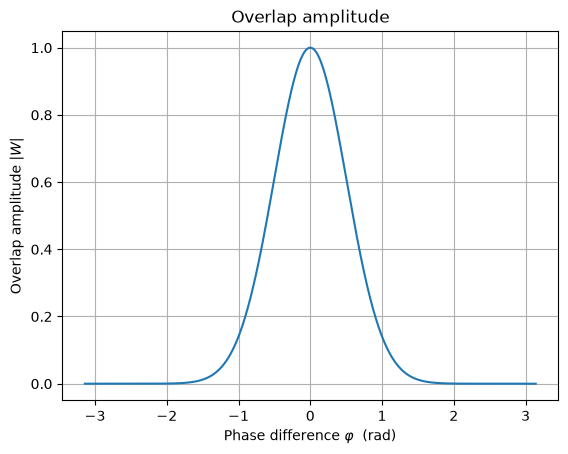

In [3]:
phase = np.linspace(-np.pi, np.pi, 10**4)

ov = Overlap(phase1=phase, phase2=0, bandwidth=B, gap=gap, num_modes=n)
W = ov.overlap()

# plot the overlap amplitude as a function of phase difference
plt.figure()
plt.plot(phase, np.abs(W))
plt.xlabel("Phase difference " r"$\varphi$  (rad)")
plt.ylabel("Overlap amplitude " r"$|W|$")
plt.title("Overlap amplitude")
plt.grid()
plt.show()

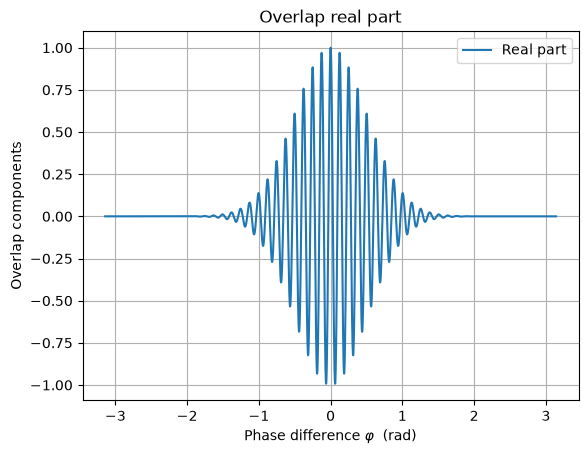

In [4]:
# plot the overlap real part as a function of phase difference
plt.figure()
plt.plot(phase, np.real(W), label="Real part")
plt.xlabel("Phase difference " r"$\varphi$  (rad)")
plt.ylabel("Overlap components")
plt.title("Overlap real part")
plt.legend()
plt.grid()
plt.show()

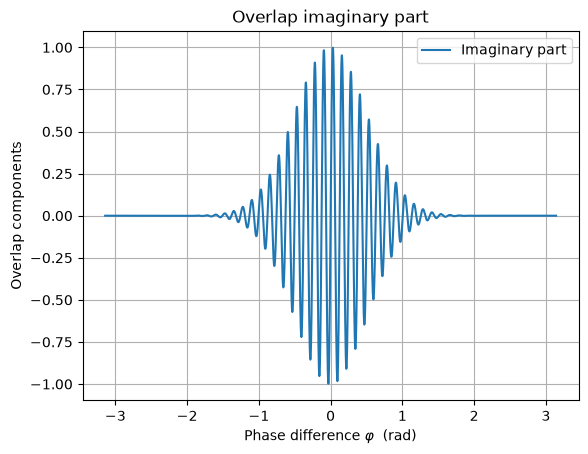

In [5]:
# plot the overlap imaginary part as a function of phase difference
plt.figure()
plt.plot(phase, np.imag(W), label="Imaginary part")
plt.xlabel("Phase difference " r"$\varphi$  (rad)")
plt.ylabel("Overlap components")
plt.title("Overlap imaginary part")
plt.legend()
plt.grid()
plt.show()

## Example 3: Generate overlap matrix

In [6]:
basis = np.linspace(-np.pi, np.pi, 51)

ov = Overlap(phase1=basis, phase2=basis, bandwidth=B, gap=gap, num_modes=n)

ov_matrix = ov.overlap_matrix()
ov_matrix.shape

(51, 51)

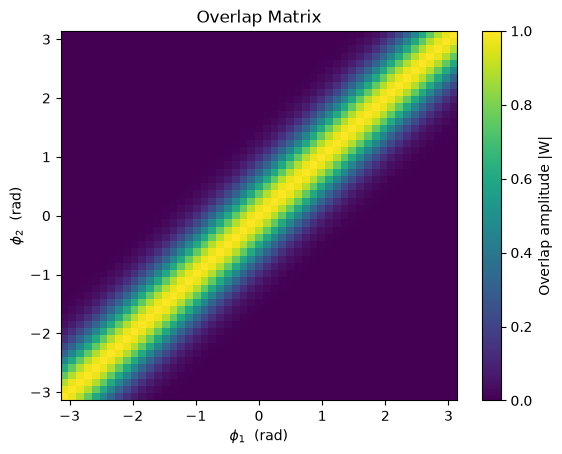

In [7]:
# visualise the overlap matrix
plt.figure()
plt.imshow(np.abs(ov_matrix), 
    extent=(-np.pi, np.pi, -np.pi, np.pi), 
    origin='lower', aspect='auto', cmap='viridis'
)
plt.colorbar(label='Overlap amplitude |W|')
plt.xlabel(r"$\phi_1$  (rad)")
plt.ylabel(r"$\phi_2$  (rad)")
plt.title("Overlap Matrix")
plt.show()

## Discussion

The overlap decreases rapidly as the phase difference increases.

For a larger number of electronic modes $n$, the overlap $\mathcal{W}$ becomes
more sharply localized around $\phi_1 = \phi_2$ consistent with Eq. (21) in the paper.